O dataset escolhido refere-se a informações sobre o estado nutricional da população, coletado do site do Portal de Dados Abertos do SUS e, devido à quantidade de aquivos, escolhemos o ano 2023 para a amostragem de análise. A fonte orginal dos dados está disponível na url: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SISVAN/estado_nutricional/sisvan_estado_nutricional_2023.zip, baixado e 23/03/2026.

No início da exploração do dataset, nos deparamos com o desafio do tamanho do arquivo (15GB), que inviabilizava o uso da biblioteca Pandas para a análise exploratória. Fizemos uma conversção da base para o formato .parquet utilizando a biblioteca duckDB (ver aquivo 'utils/file_converter.py').

Ainda assim o arquivo convertido estava muito grande (aprox. 4.5GB) então decidimos retirar uma amostra deste arquivo, baseado no município de São Paulo que, por ser o município mais populoso, teria uma amostragem considerável para o objetivo deste projeto.

Para extração dos dados utilizando novamente a bilbioteca Duck DB:

```python
ddb.query("""SELECT
    count(*) AS total_registros from 'data/sisvan_estado_nutricional_2023.parquet'
""")
```

|total_registros int64 |
| :-- | 
|53981528|

```python
ddb.query("""select COUNT(1) from 'data/sisvan_estado_nutricional_2023.parquet' WHERE no_municipio = 'SAO PAULO'""").show()
```

|  count(1) int64 |
| :-- |
| 1582936 |


```python
ddb.query("""COPY (select * from 'data/sisvan_estado_nutricional_2023.parquet' WHERE no_municipio = 'SAO PAULO') TO 'data/sao_paulo.csv' (FORMAT CSV, HEADER TRUE)""")
```

OBS.: os arquivos originais foram omitidos aqui por questões de tamanho.

A partir da extração dos dados de São Paulo iniciamos a nossa análise.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [45]:
dataset = pd.read_csv("estado_nuticional_sao_paulo.csv")

In [46]:
dataset.head(10)

,CO_ACOMPANHAMENTO,CO_PESSOA_SISVAN,ST_PARTICIPA_ANDI,CO_MUNICIPIO_IBGE,SG_UF,NO_MUNICIPIO,CO_CNES,NU_IDADE_ANO,NU_FASE_VIDA,DS_FASE_VIDA,SG_SEXO,CO_RACA_COR,DS_RACA_COR,CO_POVO_COMUNIDADE,DS_POVO_COMUNIDADE,CO_ESCOLARIDADE,DS_ESCOLARIDADE,DT_ACOMPANHAMENTO,NU_COMPETENCIA,NU_PESO,NU_ALTURA,DS_IMC,DS_IMC_PRE_GESTACIONAL,PESO X IDADE,PESO X ALTURA,CRI. ALTURA X IDADE,CRI. IMC X IDADE,ADO. ALTURA X IDADE,ADO. IMC X IDADE,CO_ESTADO_NUTRI_ADULTO,CO_ESTADO_NUTRI_IDOSO,CO_ESTADO_NUTRI_IMC_SEMGEST,CO_SISTEMA_ORIGEM_ACOMP,SISTEMA_ORIGEM_ACOMP
0,AED61CF2D71455DE20C76A7FAB9710F28B4F6A61,105EE74D6B72B7B9448BA40491FDD83D17CF3715,NaN,355030,SP,SAO PAULO,5743583.0,47,7.0,ADULTO,M,3,AMARELA,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-05,202301,"114,5",178,"36,14",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Obesidade Grau II,NaN,NaN,4,E-SUS AB
1,469F071D4DF0D4648B5EF1037DCEDE626F3DBD9E,BF9187251E573F90B6E9FA67FE401DA64A582942,NaN,355030,SP,SAO PAULO,6365817.0,62,8.0,IDOSO,F,2,PRETA,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-13,202301,65,148,"29,67",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sobrepeso,NaN,4,E-SUS AB
2,FA18DBA46C19B21017BE65805513D4C9A7F9FA7F,CA7A308F4907743DBC534E79D7C3921D5EF5F759,NaN,355030,SP,SAO PAULO,2787091.0,29,7.0,ADULTO,F,99,SEM INFORMACAO,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-10,202301,132,168,"46,77",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Obesidade Grau III,NaN,NaN,4,E-SUS AB
3,1B3A171D4793186389C1CEAABD3270634416D7AD,CF3EAD5601A1F83D438C5417670DCACE9E1A4FB2,NaN,355030,SP,SAO PAULO,6377742.0,1,2.0,ENTRE 6 MESES A 2 ANOS,F,99,SEM INFORMACAO,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-31,202301,"13,3",90,"16,42",NaN,Peso adequado para idade,Peso Adequado ou Eutrofico,Estatura adequada para a idade,Eutrofia,NaN,NaN,NaN,NaN,NaN,4,E-SUS AB
4,ED7B0E3938C6B6028030D317BC924CE6056B3782,85131329E9FA4B6E44814EFEE17849054E9B4B8D,NaN,355030,SP,SAO PAULO,2788659.0,43,7.0,ADULTO,F,1,BRANCA,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-09,202301,54,152,"23,37",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adequado ou eutrófico,NaN,NaN,4,E-SUS AB
5,F9909B40104E70EE60DB25E050C136C1C495B8BC,B75B203E53A063F0D03EA7A6929695C021855166,NaN,355030,SP,SAO PAULO,4050126.0,22,7.0,ADULTO,F,3,AMARELA,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-24,202301,"85,5",160,"33,4",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Obesidade Grau I,NaN,Obesidade,4,E-SUS AB
6,E6F88B2D594BBF0221BD9914B75B62C526CD61A8,91677ECCA114EA1D97B3BDB5500E3394C49EEC39,NaN,355030,SP,SAO PAULO,2787075.0,24,7.0,ADULTO,M,4,PARDA,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-27,202301,64,167,"22,95",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adequado ou eutrófico,NaN,NaN,4,E-SUS AB
7,B173A6998893C40302084174995A69E1D4C98F95,1AC11E94CC706778E7753465D281DC8EDDB4426A,NaN,355030,SP,SAO PAULO,2786907.0,25,7.0,ADULTO,F,99,SEM INFORMACAO,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-03,202301,49,157,"19,88",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adequado ou eutrófico,NaN,NaN,4,E-SUS AB
8,3CD3BDC0ADF1E3B190483546A0143548C996EC2B,7B518C18CC4974A402A775F018A55C2F907C4712,NaN,355030,SP,SAO PAULO,2786907.0,40,7.0,ADULTO,F,4,PARDA,NaN,NÃO INFORMADO,NaN,SEM INFORMAÇÃO,2023-01-09,202301,"71,5",150,"31,78",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Obesidade Grau I,NaN,NaN,4,E-SUS AB
9,F932C180EC14CE2FAEDA72AAF8D60D224EDA1AC1,8ED92DCD6A94D701B8A67D21D398CBF13CC09C7F,NaN,355030,SP,SAO PAULO,9460551.0,21,7.0,ADULTO,F,99,SEM INFORMACAO,NaN,NÃO INFORMADO,99.0,SEM INFORMAÇÃO,2023-01-17,202301,50,165,"18,37",NaN,NaN,NaN,NaN,NaN,NaN,NaN,Baixo peso,NaN,NaN,4,E-SUS AB


In [47]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1582936 entries, 0 to 1582935
Data columns (total 34 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   CO_ACOMPANHAMENTO            1582936 non-null  str    
 1   CO_PESSOA_SISVAN             1582936 non-null  str    
 2   ST_PARTICIPA_ANDI            0 non-null        float64
 3   CO_MUNICIPIO_IBGE            1582936 non-null  int64  
 4   SG_UF                        1582936 non-null  str    
 5   NO_MUNICIPIO                 1582936 non-null  str    
 6   CO_CNES                      1582935 non-null  float64
 7   NU_IDADE_ANO                 1582936 non-null  int64  
 8   NU_FASE_VIDA                 1582936 non-null  float64
 9   DS_FASE_VIDA                 1582936 non-null  str    
 10  SG_SEXO                      1582936 non-null  str    
 11  CO_RACA_COR                  1582936 non-null  int64  
 12  DS_RACA_COR                  1582936 non-null  str   

Importamos uma base com informações da situação nutricional das pessoas da cidade de São Paulo/SP no período de Janeiro de 2022 à Dezembro de 2023 para treinar nosso modelo.

O objetivo é treinar o modelo para ele analisar dados como idade, altura, peso, etc... e definir em qual estado nutricional estão as pessoas, Magreza, Sobrepeso, Obesidade, etc...

Avaliando os primeiros e últimos registros da base de dados, podemos notar a preseça de algumas colunas irrelevantes para o treinamento do modelo, como códigos de sistemas e datas. 

Além disso, muitas colunas aparecem totalmente nulas e outras majoritariamente nulas, sendo que aplicar uma mediana não seria adequado porque são dados determiníticos, como 'DS_POVO_COMUNIDADE', que é a comunidade aonde a pessoa reside. Não tem uma técnica para "adivinhar" em qual comunidade a pessoa reside.

Abaixo temos a relação de colunas que vamos remover da base para trabalharmos somente com dados relevantes para o treinamento.

| Coluna | Motivo da Remoção |
| :--- | :--- |
| `ST_PARTICIPA_ANDI` | Dado irrelevante (participação no programa ANDI). |
| `CO_POVO_COMUNIDADE` | Majoritariamente nulo. |
| `DS_IMC_PRE_GESTACIONAL` | Todos os registros são nulos. |
| `CO_ESCOLARIDADE` | Majoritariamente nulo. |
| `DS_ESCOLARIDADE` | Maioria dos dados consta como "SEM INFORMAÇÃO". |
| `CO_ACOMPANHAMENTO` | Código técnico/sistema irrelevante para o modelo. |
| `CO_PESSOA_SISVAN` | Código de identificação irrelevante. |
| `CO_MUNICIPIO_IBGE` | Valor constante (Todos são SÃO PAULO). |
| `SG_UF` | Valor constante (Todos são SÃO PAULO). |
| `NO_MUNICIPIO` | Valor constante (Todos são SÃO PAULO). |
| `CO_CNES` | Código de estabelecimento irrelevante. |
| `DS_POVO_COMUNIDADE` | Maioria dos dados consta como "NÃO INFORMADO". |
| `NU_COMPETENCIA` | Referência temporal (mês/ano) irrelevante para o estado nutricional. |
| `CO_SISTEMA_ORIGEM_ACOMP` | Código de sistema irrelevante. |
| `SISTEMA_ORIGEM_ACOMP` | Informação de origem do dado irrelevante. |
| `DT_ACOMPANHAMENTO` | Data do registro, irrelevante para a predição atual. |
| `PESO X IDADE` | Específico apenas para faixa etária de 0 a 10 anos. |
| `CRI. ALTURA X IDADE` | Específico apenas para faixa etária de 0 a 10 anos. |
| `ADO. ALTURA X IDADE` | Específico apenas para faixa etária de 10 a menos de 20 anos. |
| `PESO X ALTURA` | Informação redundante (contida na coluna CRI. IMC X IDADE). |  

OBS.: Qualquer dúvida sobre os dados, vide o arquivo 'Dicionário_de_Dados_Estado_Nutricional.pdf' que está inclúso neste projeto.

Agora vamos analisar o quadro das gestantes que estão na base. Vamos ver quantos registros temos com a coluna 'CO_ESTADO_NUTRI_IMC_SEMGEST' preenchida.

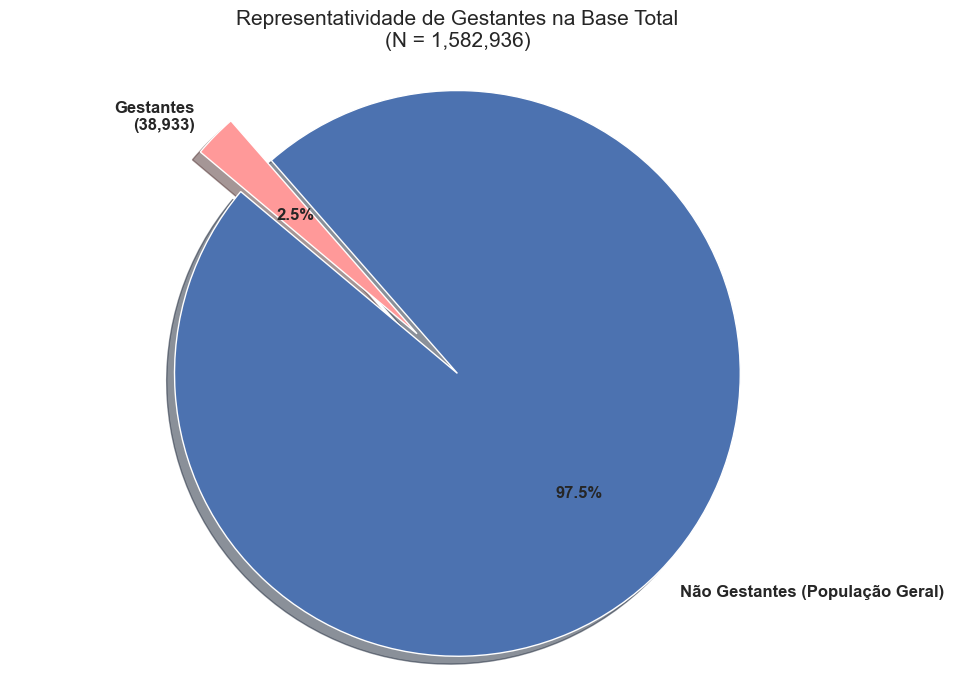

In [48]:
total_dataset = len(dataset)
total_gestantes = dataset["CO_ESTADO_NUTRI_IMC_SEMGEST"].notna().sum()
total_nao_gestantes = total_dataset - total_gestantes

labels = ['Não Gestantes (População Geral)', f'Gestantes\n({total_gestantes:,})']
sizes = [total_nao_gestantes, total_gestantes]
colors = ['#4c72b0', '#ff9999'] # Azul padrão e um Vermelho/Rosa para destaque
explode = (0, 0.2)  # "Puxa" a fatia das gestantes para fora para dar ênfase

plt.figure(figsize=(10, 7))
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        colors=colors, 
        autopct='%1.1f%%', # Mostra a porcentagem com uma casa decimal
        shadow=True, 
        startangle=140,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title(f'Representatividade de Gestantes na Base Total\n(N = {total_dataset:,})', fontsize=15, pad=20)
plt.axis('equal')

plt.tight_layout()
plt.show()

Como são poucos dados diante de uma base com mais 1.5 milhões de registro e não possuímos mais informações sobre esse grupo de pessoas(como a semana de gestação) para o modelo entender isso e não avaliar uma pessoa normal dentro dos parametros de grávidas sem estas estarém grávidas, vamos remover essas pessoas da base assim como esta coluna também.

In [49]:
clean_dataset = dataset[dataset["CO_ESTADO_NUTRI_IMC_SEMGEST"].isna()]
clean_dataset.drop(columns=[
                                "ST_PARTICIPA_ANDI", # Irrelevante: Se o municipio participa do programa ANDI
                                "CO_POVO_COMUNIDADE", # A maioria é nulo
                                "DS_IMC_PRE_GESTACIONAL", # Todos nulos
                                "CO_ESCOLARIDADE", # A maioria é nulo
                                "DS_ESCOLARIDADE", # A maioria é SEM INFORMAÇÃO
                                "CO_ACOMPANHAMENTO", # Código irrelevante
                                "CO_PESSOA_SISVAN", # Código irrelevante
                                "CO_MUNICIPIO_IBGE", # Todos são SÃO PAULO
                                "SG_UF", # Todos são SÃO PAULO
                                "NO_MUNICIPIO", # Todos são SÃO PAULO
                                "CO_CNES", # Código irrelevante
                                "DS_POVO_COMUNIDADE", # A maioria é NÃO INFORMADO
                                "NU_COMPETENCIA", # Ano/Mês do acompanhamento, irrelevante neste caso
                                "CO_SISTEMA_ORIGEM_ACOMP", # Código irrelevante
                                "SISTEMA_ORIGEM_ACOMP", # Informação irrelevante
                                "DT_ACOMPANHAMENTO", # Data, irrelevante neste caso
                                "PESO X IDADE", # Somente para as idades de 0 a 10 anos
                                "CRI. ALTURA X IDADE", # Somente de 0 a 10 anos
                                "ADO. ALTURA X IDADE", # Somente de 10 a menos de 20 anos
                                "PESO X ALTURA", # Tem na coluna CRI. IMC X IDADE
                                "CO_ESTADO_NUTRI_IMC_SEMGEST", # Não temos mais informações sobre o grupo para não confundir o modelo
                                "NU_FASE_VIDA", # Código da fase da voda
                                "CO_RACA_COR", # Código da raça
                            ], inplace=True)

In [50]:
clean_dataset.info()

<class 'pandas.DataFrame'>
Index: 1544003 entries, 0 to 1582935
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   NU_IDADE_ANO            1544003 non-null  int64
 1   DS_FASE_VIDA            1544003 non-null  str  
 2   SG_SEXO                 1544003 non-null  str  
 3   DS_RACA_COR             1544003 non-null  str  
 4   NU_PESO                 1544003 non-null  str  
 5   NU_ALTURA               1544003 non-null  str  
 6   DS_IMC                  1544003 non-null  str  
 7   CRI. IMC X IDADE        347082 non-null   str  
 8   ADO. IMC X IDADE        185834 non-null   str  
 9   CO_ESTADO_NUTRI_ADULTO  691382 non-null   str  
 10  CO_ESTADO_NUTRI_IDOSO   309055 non-null   str  
dtypes: int64(1), str(10)
memory usage: 141.4 MB


Com base limpa, podemos ver que as colunas restantes conetem bem menos informações nulas e nenhuma irrelevante para o treinamento.

Abaixo temos a relação de colunas variáveis, que são os dados a serem analisados para chegar na conclusão final que é o estado nutricional da pessoa.
Note que temos todos os dados preenchidos sem nulos em nenhum registro.

| # | Column | Non-Null Count | Dtype |
|---| :--- | :--- | :--- |
| 0 | NU_IDADE_ANO | 1.582.936 | int64 |
| 1 | DS_FASE_VIDA | 1.582.936 | str |
| 2 | SG_SEXO | 1.582.936 | str |
| 3 | DS_RACA_COR | 1.582.936 | str |
| 4 | NU_PESO | 1.582.936 | float64 |
| 5 | NU_ALTURA | 1.582.936 | float64 |
| 6 | DS_IMC | 1.582.936 | float64 |

 Os dados como idade, fase de vida, sexo, raça/cor, peso, altura e IMC serão analisados para chegar na conclusão final, nosso alvo (target).

 Anaisando os dados atuais, após a limpeza, notamos que nosso target está distribuído em 4 colunas diferentes que se diferenciam pela faixa etária dos indivíduos.

| # | Column | Non-Null Count | Dtype |
|---| :--- | :--- | :--- |
| 9 | CRI. IMC X IDADE | 347.088 | str |
| 10 | ADO. IMC X IDADE | 190.113 | str |
| 11 | CO_ESTADO_NUTRI_ADULTO | 725.655 | str |
| 12 | CO_ESTADO_NUTRI_IDOSO | 309.080 | str |

A coluna 'CRI. IMC X IDADE' traz informações de pessoas entre 0 a 10 anos, aonde os valores são: 'Magreza acentuada’, ‘Magreza’, ‘Eutrofia', 'Riscode sobrepeso', 'Sobrepeso', 'Obesidade'. Nas demais pessoas fora desta faixa de idade, essa coluna tera a informação nula.

Ja a coluna 'ADO. IMC X IDADE' traz informações de pessoas entre 10 e 20 anos, aonde os valores são: Magreza acentuada', 'Magreza', 'Eutrofia', 'Risco de sobrepeso','Sobrepeso', 'Obesidade'. As pessoas fora desta faixa de idade terão essa coluna nula.

A coluna 'CO_ESTADO_NUTRI_ADULTO' traz informações de pessoas entre 20 e 60 anos, aonde os valores são: 'Baixo peso', 'Adequado ou Eutrófico', 'Sobrepeso', 'Obesidade Grau I','Obesidade Grau II', 'Obesidade Grau III'. Note aqui o resultado é um pouco diferente, a obesidade se divide em 3 graus. Isso porque só é possível medir com essa precisão em pessoas nesta faixa etária.

A colina 'CO_ESTADO_NUTRI_IDOSO' traz informações de pessoas com 60 anos ou mais, aonde os valores são: 'Baixo peso', 'Adequado ou Eutrófico','Sobrepeso'

Agora vamos analisar se todos os 1.582.936 registros possuem alguma das informações alvo (target) sem a informação de gestantes (CO_ESTADO_NUTRI_IMC_SEMGEST).

In [51]:
filtro = (
    clean_dataset['CRI. IMC X IDADE'].isna() & 
    clean_dataset['ADO. IMC X IDADE'].isna() & 
    clean_dataset['CO_ESTADO_NUTRI_ADULTO'].isna() & 
    clean_dataset['CO_ESTADO_NUTRI_IDOSO'].isna()
)

print(f"Total sem NENHUM target: {len(clean_dataset[filtro])} de {len(clean_dataset)}")

Total sem NENHUM target: 10650 de 1544003


Ficamos com apenas 10650 registros sem o target, o que é muito bom.

### Classificação do Estado Nutricional por Grupo (Targets)

*   **CRI. IMC X IDADE** (0 a 10 anos)
    *   **Valores:** `Magreza acentuada`, `Magreza`, `Eutrofia`, `Risco de sobrepeso`, `Sobrepeso`, `Obesidade`.
*   **ADO. IMC X IDADE** (10 a menos de 20 anos)
    *   **Valores:** `Magreza acentuada`, `Magreza`, `Eutrofia`, `Risco de sobrepeso`, `Sobrepeso`, `Obesidade`.
*   **CO_ESTADO_NUTRI_ADULTO** (20 a 60 anos)
    *   **Valores:** `Baixo peso`, `Adequado ou Eutrófico`, `Sobrepeso`, `Obesidade Grau I`, `Obesidade Grau II`, `Obesidade Grau III`.
*   **CO_ESTADO_NUTRI_IDOSO** (60 anos ou mais)
    *   **Valores:** `Baixo peso`, `Adequado ou Eutrófico`, `Sobrepeso`.

Com esta análise, podemos juntar os targets em uma única coluna unifique os estados de nutrição

| # | Descrição | Grupo SISVAN |
| :--- | :--- | :--- |
| 0 | Magreza Acentuada | 'Magreza acentuada' |
| 1 | Baixo Peso | 'Magreza', 'Baixo peso' |
| 2 | Eutrofia (Normal) | 'Eutrofia', 'Adequado ou Eutrófico' |
| 3 | Risco/Sobrepeso | 'Risco de sobrepeso', 'Sobrepeso' |
| 4 | Obesidade | 'Obesidade', 'Obesidade Grau I' |
| 5 | Obesidade Grave | 'Obesidade Grau II', 'Obesidade Grau III' |



In [52]:
# Metódo não performático
#clean_dataset["ESTADO_NUTRI"] = clean_dataset['CRI. IMC X IDADE']\
#    .combine_first(clean_dataset['ADO. IMC X IDADE'])\
#    .combine_first(clean_dataset['CO_ESTADO_NUTRI_ADULTO'])\
#    .combine_first(clean_dataset['CO_ESTADO_NUTRI_IDOSO'])

# Método meio performático
colunas = [
    'CRI. IMC X IDADE',
    'ADO. IMC X IDADE',
    'CO_ESTADO_NUTRI_ADULTO',
    'CO_ESTADO_NUTRI_IDOSO',
]

# Ele "empurra" o primeiro valor encontrado da esquerda para a direita
clean_dataset['ESTADO_NUTRI'] = clean_dataset[colunas].bfill(axis=1).iloc[:, 0]

# OBS.: Existe um método mais performárico (e mais complexo) com numpyn
# mas para esta base de dados o 'bfill' vai atender bem, demorou uns 50s para realizar esta operação.

clean_dataset.info()

<class 'pandas.DataFrame'>
Index: 1544003 entries, 0 to 1582935
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   NU_IDADE_ANO            1544003 non-null  int64
 1   DS_FASE_VIDA            1544003 non-null  str  
 2   SG_SEXO                 1544003 non-null  str  
 3   DS_RACA_COR             1544003 non-null  str  
 4   NU_PESO                 1544003 non-null  str  
 5   NU_ALTURA               1544003 non-null  str  
 6   DS_IMC                  1544003 non-null  str  
 7   CRI. IMC X IDADE        347082 non-null   str  
 8   ADO. IMC X IDADE        185834 non-null   str  
 9   CO_ESTADO_NUTRI_ADULTO  691382 non-null   str  
 10  CO_ESTADO_NUTRI_IDOSO   309055 non-null   str  
 11  ESTADO_NUTRI            1533353 non-null  str  
dtypes: int64(1), str(11)
memory usage: 153.1 MB


Com a nova coluna 'ESTADO_NUTRI' consolidada, podemos ver que 1572286 dos 1582936 registros foram classificados com sucesso.

Com a nova coluna target estabelecida, podemos remover as demais que foram usadas para gerá-la.

In [53]:
clean_target_dataset = clean_dataset.drop(columns=[
                                                    "CRI. IMC X IDADE",
                                                    "ADO. IMC X IDADE",
                                                    "CO_ESTADO_NUTRI_ADULTO",
                                                    "CO_ESTADO_NUTRI_IDOSO"
                                                    ])

clean_target_dataset.info()

<class 'pandas.DataFrame'>
Index: 1544003 entries, 0 to 1582935
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype
---  ------        --------------    -----
 0   NU_IDADE_ANO  1544003 non-null  int64
 1   DS_FASE_VIDA  1544003 non-null  str  
 2   SG_SEXO       1544003 non-null  str  
 3   DS_RACA_COR   1544003 non-null  str  
 4   NU_PESO       1544003 non-null  str  
 5   NU_ALTURA     1544003 non-null  str  
 6   DS_IMC        1544003 non-null  str  
 7   ESTADO_NUTRI  1533353 non-null  str  
dtypes: int64(1), str(7)
memory usage: 106.0 MB


Com a base quase limpa e com um único target estabelecido, vamos ver quantos e quais registros não conseguiram nenhuma classificação.

In [54]:
print(f"Quantidade de registros SEM classificação(ESTADO_NUTRI): {len(clean_target_dataset[clean_target_dataset["ESTADO_NUTRI"].isna()])}")

Quantidade de registros SEM classificação(ESTADO_NUTRI): 10650


In [55]:
clean_target_dataset[clean_target_dataset["ESTADO_NUTRI"].isna()].head(10)

,NU_IDADE_ANO,DS_FASE_VIDA,SG_SEXO,DS_RACA_COR,NU_PESO,NU_ALTURA,DS_IMC,ESTADO_NUTRI
166,37,ADULTO,F,BRANCA,72,170,"24,91",NaN
279,53,ADULTO,F,SEM INFORMACAO,"67,1",164,"24,95",NaN
286,47,ADULTO,M,SEM INFORMACAO,"76,5",175,"24,98",NaN
373,47,ADULTO,F,PARDA,"81,5",165,"29,94",NaN
670,24,ADULTO,F,PARDA,60,155,"24,97",NaN
750,65,IDOSO,M,SEM INFORMACAO,66,"156,5","26,95",NaN
863,20,ADULTO,F,SEM INFORMACAO,60,155,"24,97",NaN
990,46,ADULTO,F,PARDA,60,155,"24,97",NaN
1115,46,ADULTO,F,SEM INFORMACAO,"59,1",154,"24,92",NaN
1132,47,ADULTO,F,SEM INFORMACAO,72,155,"29,97",NaN


Como a base possui mais de 1.5 milhões de registro, remover esta pequena quantidade de 10650 sem classificação não vai prejudicar o trenamento do modelo.

Vamos fazer isso e analisar os dados novamente.

In [56]:
clean_target_dataset.dropna(subset=['ESTADO_NUTRI'], inplace=True)

clean_target_dataset.info()

<class 'pandas.DataFrame'>
Index: 1533353 entries, 0 to 1582935
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype
---  ------        --------------    -----
 0   NU_IDADE_ANO  1533353 non-null  int64
 1   DS_FASE_VIDA  1533353 non-null  str  
 2   SG_SEXO       1533353 non-null  str  
 3   DS_RACA_COR   1533353 non-null  str  
 4   NU_PESO       1533353 non-null  str  
 5   NU_ALTURA     1533353 non-null  str  
 6   DS_IMC        1533353 non-null  str  
 7   ESTADO_NUTRI  1533353 non-null  str  
dtypes: int64(1), str(7)
memory usage: 105.3 MB


In [57]:
clean_target_dataset.head(10)

,NU_IDADE_ANO,DS_FASE_VIDA,SG_SEXO,DS_RACA_COR,NU_PESO,NU_ALTURA,DS_IMC,ESTADO_NUTRI
0,47,ADULTO,M,AMARELA,"114,5",178,"36,14",Obesidade Grau II
1,62,IDOSO,F,PRETA,65,148,"29,67",Sobrepeso
2,29,ADULTO,F,SEM INFORMACAO,132,168,"46,77",Obesidade Grau III
3,1,ENTRE 6 MESES A 2 ANOS,F,SEM INFORMACAO,"13,3",90,"16,42",Eutrofia
4,43,ADULTO,F,BRANCA,54,152,"23,37",Adequado ou eutrófico
6,24,ADULTO,M,PARDA,64,167,"22,95",Adequado ou eutrófico
7,25,ADULTO,F,SEM INFORMACAO,49,157,"19,88",Adequado ou eutrófico
8,40,ADULTO,F,PARDA,"71,5",150,"31,78",Obesidade Grau I
9,21,ADULTO,F,SEM INFORMACAO,50,165,"18,37",Baixo peso
10,74,IDOSO,F,PRETA,85,160,"33,2",Sobrepeso


Note que as colunas 'NU_PESO', 'NU_ALTURA' e 'DS_IMC' são dados numéricos representados como strings.  
Vamos aplicar uma correção nessas colunas para termos sucesso no treinamento do modelo.

In [58]:
clean_target_dataset["DS_IMC"] = clean_target_dataset["DS_IMC"].str.strip().str.replace(",", ".").astype(float)
clean_target_dataset["NU_PESO"] = clean_target_dataset["NU_PESO"].str.strip().str.replace(",", ".").astype(float)
clean_target_dataset["NU_ALTURA"] = clean_target_dataset["NU_ALTURA"].str.strip().str.replace(",", ".").astype(float)

clean_target_dataset.head(10)

,NU_IDADE_ANO,DS_FASE_VIDA,SG_SEXO,DS_RACA_COR,NU_PESO,NU_ALTURA,DS_IMC,ESTADO_NUTRI
0,47,ADULTO,M,AMARELA,114.5,178.0,36.14,Obesidade Grau II
1,62,IDOSO,F,PRETA,65.0,148.0,29.67,Sobrepeso
2,29,ADULTO,F,SEM INFORMACAO,132.0,168.0,46.77,Obesidade Grau III
3,1,ENTRE 6 MESES A 2 ANOS,F,SEM INFORMACAO,13.3,90.0,16.42,Eutrofia
4,43,ADULTO,F,BRANCA,54.0,152.0,23.37,Adequado ou eutrófico
6,24,ADULTO,M,PARDA,64.0,167.0,22.95,Adequado ou eutrófico
7,25,ADULTO,F,SEM INFORMACAO,49.0,157.0,19.88,Adequado ou eutrófico
8,40,ADULTO,F,PARDA,71.5,150.0,31.78,Obesidade Grau I
9,21,ADULTO,F,SEM INFORMACAO,50.0,165.0,18.37,Baixo peso
10,74,IDOSO,F,PRETA,85.0,160.0,33.20,Sobrepeso


In [59]:
clean_target_dataset.info()

<class 'pandas.DataFrame'>
Index: 1533353 entries, 0 to 1582935
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   NU_IDADE_ANO  1533353 non-null  int64  
 1   DS_FASE_VIDA  1533353 non-null  str    
 2   SG_SEXO       1533353 non-null  str    
 3   DS_RACA_COR   1533353 non-null  str    
 4   NU_PESO       1533353 non-null  float64
 5   NU_ALTURA     1533353 non-null  float64
 6   DS_IMC        1533353 non-null  float64
 7   ESTADO_NUTRI  1533353 non-null  str    
dtypes: float64(3), int64(1), str(4)
memory usage: 105.3 MB


O grafico a seguir mostra que cor/raça tem baixa relevância (as barras tem tamanhos e coloracao semelhantes) no estado de nutricao.  
Além disso, essa informação não é diretamente ligada ao estado nutricional das pessoas e também possui muitas informada como SEM INFORMAÇÃO.  
Isso pode atrapalhar o aprendizado do modelo.  
Portanto 'DS_RACA_COR' pode ser removida.  

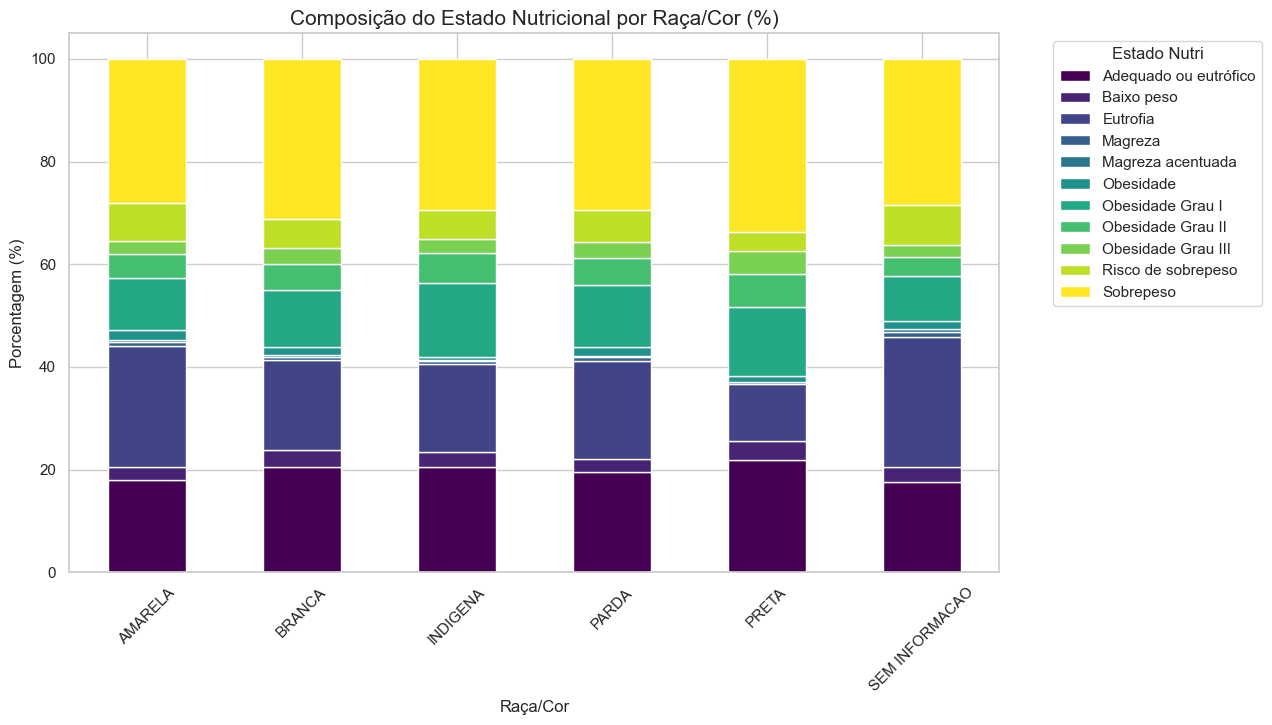

In [60]:
prop_raca = pd.crosstab(clean_target_dataset["DS_RACA_COR"], clean_target_dataset["ESTADO_NUTRI"], normalize='index') * 100

prop_raca.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Composição do Estado Nutricional por Raça/Cor (%)', fontsize=15)
plt.legend(title='Estado Nutri', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Raça/Cor')
plt.xticks(rotation=45)
plt.show()

In [61]:
clean_target_dataset.drop("DS_RACA_COR", axis=1, inplace=True)
clean_target_dataset.info()

<class 'pandas.DataFrame'>
Index: 1533353 entries, 0 to 1582935
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   NU_IDADE_ANO  1533353 non-null  int64  
 1   DS_FASE_VIDA  1533353 non-null  str    
 2   SG_SEXO       1533353 non-null  str    
 3   NU_PESO       1533353 non-null  float64
 4   NU_ALTURA     1533353 non-null  float64
 5   DS_IMC        1533353 non-null  float64
 6   ESTADO_NUTRI  1533353 non-null  str    
dtypes: float64(3), int64(1), str(3)
memory usage: 93.6 MB


Agora sim, com a base limpa e ajustada, aonde temos todos os dados com valores e alvos informados, com seus devidos tipos, vamos transformar os textos em números utilizando o LabelEncoder, da 'sklearn'

In [62]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

clean_target_encoded_dataset = clean_target_dataset.copy()
clean_target_encoded_dataset["DS_FASE_VIDA"] = encoder.fit_transform(clean_target_encoded_dataset["DS_FASE_VIDA"])
clean_target_encoded_dataset["SG_SEXO"] = encoder.fit_transform(clean_target_encoded_dataset["SG_SEXO"])

clean_target_encoded_dataset.info()

<class 'pandas.DataFrame'>
Index: 1533353 entries, 0 to 1582935
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   NU_IDADE_ANO  1533353 non-null  int64  
 1   DS_FASE_VIDA  1533353 non-null  int64  
 2   SG_SEXO       1533353 non-null  int64  
 3   NU_PESO       1533353 non-null  float64
 4   NU_ALTURA     1533353 non-null  float64
 5   DS_IMC        1533353 non-null  float64
 6   ESTADO_NUTRI  1533353 non-null  str    
dtypes: float64(3), int64(3), str(1)
memory usage: 93.6 MB


In [63]:
clean_target_encoded_dataset.head(10)

,NU_IDADE_ANO,DS_FASE_VIDA,SG_SEXO,NU_PESO,NU_ALTURA,DS_IMC,ESTADO_NUTRI
0,47,1,1,114.5,178.0,36.14,Obesidade Grau II
1,62,6,0,65.0,148.0,29.67,Sobrepeso
2,29,1,0,132.0,168.0,46.77,Obesidade Grau III
3,1,4,0,13.3,90.0,16.42,Eutrofia
4,43,1,0,54.0,152.0,23.37,Adequado ou eutrófico
6,24,1,1,64.0,167.0,22.95,Adequado ou eutrófico
7,25,1,0,49.0,157.0,19.88,Adequado ou eutrófico
8,40,1,0,71.5,150.0,31.78,Obesidade Grau I
9,21,1,0,50.0,165.0,18.37,Baixo peso
10,74,6,0,85.0,160.0,33.20,Sobrepeso


In [64]:
clean_target_dataset.head(10)

,NU_IDADE_ANO,DS_FASE_VIDA,SG_SEXO,NU_PESO,NU_ALTURA,DS_IMC,ESTADO_NUTRI
0,47,ADULTO,M,114.5,178.0,36.14,Obesidade Grau II
1,62,IDOSO,F,65.0,148.0,29.67,Sobrepeso
2,29,ADULTO,F,132.0,168.0,46.77,Obesidade Grau III
3,1,ENTRE 6 MESES A 2 ANOS,F,13.3,90.0,16.42,Eutrofia
4,43,ADULTO,F,54.0,152.0,23.37,Adequado ou eutrófico
6,24,ADULTO,M,64.0,167.0,22.95,Adequado ou eutrófico
7,25,ADULTO,F,49.0,157.0,19.88,Adequado ou eutrófico
8,40,ADULTO,F,71.5,150.0,31.78,Obesidade Grau I
9,21,ADULTO,F,50.0,165.0,18.37,Baixo peso
10,74,IDOSO,F,85.0,160.0,33.20,Sobrepeso


array([[<Axes: title={'center': 'NU_IDADE_ANO'}>,
        <Axes: title={'center': 'DS_FASE_VIDA'}>],
       [<Axes: title={'center': 'SG_SEXO'}>,
        <Axes: title={'center': 'NU_PESO'}>],
       [<Axes: title={'center': 'NU_ALTURA'}>,
        <Axes: title={'center': 'DS_IMC'}>]], dtype=object)

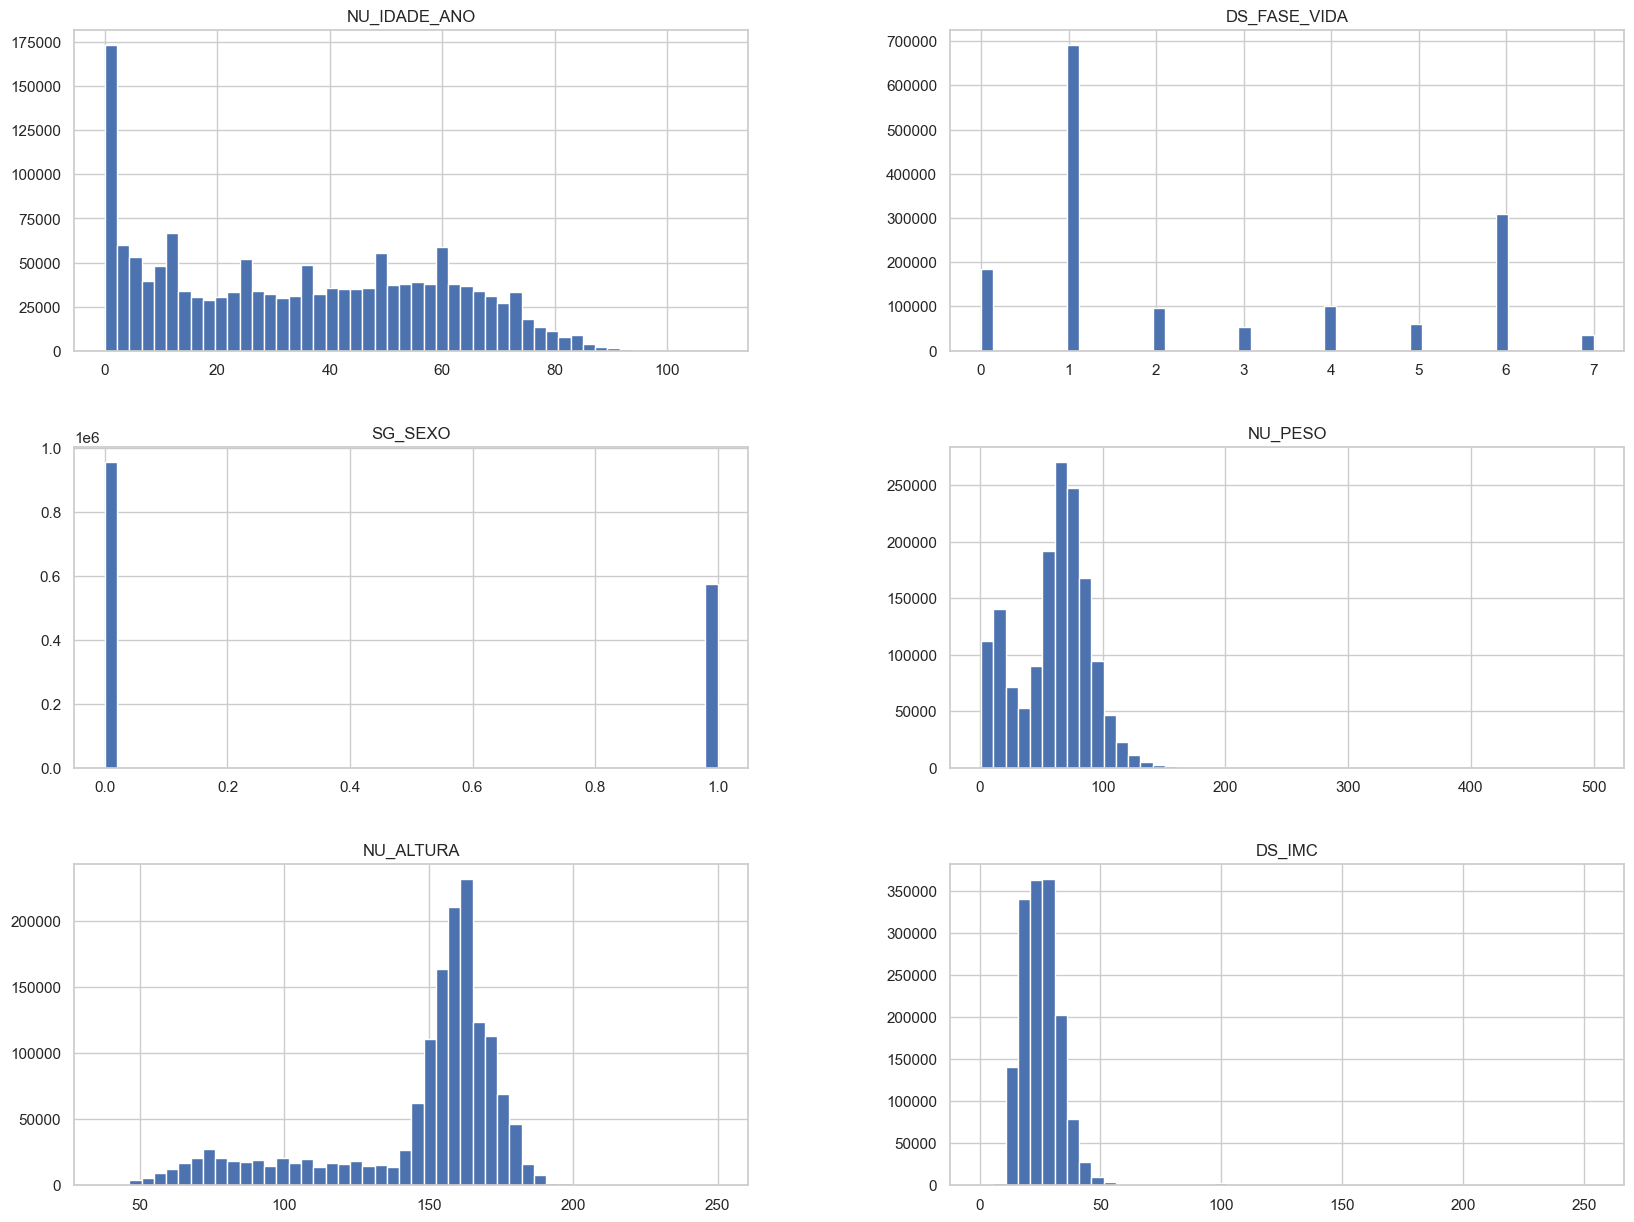

In [65]:
clean_target_encoded_dataset.hist(bins=50, figsize=(20,15))

Em 'NU_IDADE_ANO' podemos notar que existe uma grande concentração de pessoas entre 0 e 2 anos.  
O modelo pode aprender mais sobre essa faixa etária e menos sobre as outras.

In [66]:
ds0_2_anos = clean_target_encoded_dataset[clean_target_encoded_dataset["NU_IDADE_ANO"] >= 0]
ds0_2_anos = ds0_2_anos[ds0_2_anos["NU_IDADE_ANO"] <=2]
print(f"Quantidade de pessoas entre 0 e 2 anos: {ds0_2_anos["NU_IDADE_ANO"].value_counts().sum()}")

Quantidade de pessoas entre 0 e 2 anos: 173408


Ainda na mesma coluna, podemos notar outliers a partir dos 80 anos, isso é, temos poucos exemplares nesta faixa etária para treinar o modelo.  
Provavelmente ele tera mais dificuldade de classificar outras pessoas com com mais de 80 anos.

In [67]:
ds_80_plus = clean_target_encoded_dataset[clean_target_encoded_dataset["NU_IDADE_ANO"] >= 80]
ds_80_plus["NU_IDADE_ANO"].value_counts()

NU_IDADE_ANO
80     5129
81     4278
83     3674
82     3586
84     2920
85     2436
86     1966
87     1666
88     1348
89      975
90      750
91      626
92      480
93      377
94      285
95      217
96      150
97      103
98       71
99       33
100      30
101      16
104       7
102       6
109       4
105       4
106       3
103       3
108       3
107       3
Name: count, dtype: int64

In [68]:
print(f"Quantidade de pessoas com 80 ou mais: {ds_80_plus["NU_IDADE_ANO"].value_counts().sum()}")

Quantidade de pessoas com 80 ou mais: 31149


Já na coluna 'DS_FASE_VIDA' podemos ver uma maior concentração de dados em adultos e Idosos.  
Isso pode fazer com que nosso modelo fique melhor para classificar nessas fases de vida do que nas demais.  

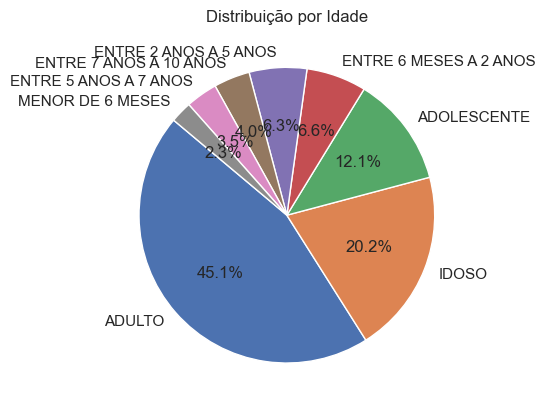

In [69]:
count_fase_vida = clean_target_dataset["DS_FASE_VIDA"].value_counts() # Aqui usamos o dataset sem encode para ver o nome das faixa etárias

count_fase_vida.plot(kind='pie', autopct='%1.1f%%', startangle=140)

plt.title('Distribuição por Idade')
plt.ylabel('')
plt.show()

Na coluna 'NU_PESO' temos muitos outliers com 150kg ou mais, sendo que tem pessoas com mais de 300 kg, e 3 pessoas 50 500 kg.  
Será que isso é erro de digitação?

In [70]:
clean_target_encoded_dataset[clean_target_encoded_dataset["NU_PESO"] >= 150]["NU_PESO"].value_counts().sort_index(ascending=False)

NU_PESO
500.000      3
499.000      1
498.600      1
498.000      2
497.000      1
496.000      1
495.000      1
490.500      1
490.000      1
488.000      1
487.000      1
486.000      1
485.000      1
481.000      1
480.000      3
478.000      2
476.000      1
475.000      1
474.000      2
473.000      1
469.000      1
468.000      1
464.000      1
463.000      2
460.000      1
458.000      1
457.000      1
456.000      1
454.000      1
452.200      1
450.000      4
448.000      1
447.000      2
446.000      1
445.000      1
442.000      2
441.000      1
439.000      1
436.000      1
434.000      1
433.000      1
427.000      3
426.000      1
425.000      1
416.000      2
415.000      1
414.800      1
410.000      1
408.000      1
405.000      1
402.000      2
398.000      1
396.000      1
395.000      1
392.786      1
389.000      1
388.000      1
387.000      1
384.000      1
383.000      2
376.000      1
369.600      1
367.000      1
366.000      1
365.000      2
360.000      1
35

Ja na coluna 'NU_ALTURA', vemos uma grande concentração de pessoas abaixo de 140 cm, isso faz sentido porque, como vimos antes, temos uma maior concentração de crianças nessa base de dados.

In [71]:
print(f"Numero de pessoas com 140 cm ou menos: \
{clean_target_encoded_dataset[clean_target_encoded_dataset["NU_ALTURA"] <= 140]["NU_ALTURA"].value_counts().sum()}")

Numero de pessoas com 140 cm ou menos: 356033


Por outro lado, temos uma concentração bem menor (outliers) de pessoas com 190 cm ou mais.

In [72]:
print(f"Numero de pessoas com 190 cm ou mais: \
{clean_target_encoded_dataset[clean_target_encoded_dataset["NU_ALTURA"] >= 190]["NU_ALTURA"].value_counts().sum()}")

Numero de pessoas com 190 cm ou mais: 4971


Analisando a coluna 'DS_IMC', notamos que temos uma boa concentração de pessoas com 15 ou menos de IMC, o que faz sentido, ja que a base possui mais criançar.  
E uma baixa concentração com muitos outliers com imc 52 ou maior.  

In [73]:
print(f"Pessoas com IMC 15 ou menos: {clean_target_encoded_dataset[clean_target_encoded_dataset["DS_IMC"] <= 15]["DS_IMC"].value_counts().sum()}")

Pessoas com IMC 15 ou menos: 84894


In [74]:
print(f"Pessoas com IMC 52 ou maior: {clean_target_encoded_dataset[clean_target_encoded_dataset["DS_IMC"] >= 52]["DS_IMC"].value_counts().sum()}")

Pessoas com IMC 52 ou maior: 6522


O grafico a seguir mostra os outliers do IMC. IMC acima de 120 é improvavel. Tem um espaço muito grande entre ~60 e 100. Isso é um erro de digitação? 

In [75]:
clean_target_encoded_dataset[clean_target_encoded_dataset["DS_IMC"] >= 120]["DS_IMC"].value_counts().sort_index(ascending=False)

DS_IMC
254.00    1
247.96    1
246.48    1
239.62    1
238.54    1
230.11    1
224.95    1
222.22    1
221.60    1
215.55    1
215.08    1
210.67    1
208.12    1
204.50    1
202.40    1
201.78    1
200.40    1
200.00    2
198.96    1
197.79    1
196.42    1
195.65    1
194.73    1
184.91    1
182.41    1
180.23    1
178.13    1
175.06    1
174.62    1
173.45    1
171.47    1
170.67    1
152.54    1
149.98    1
145.22    1
141.87    1
135.12    1
133.14    1
132.54    1
128.40    1
120.00    1
Name: count, dtype: int64

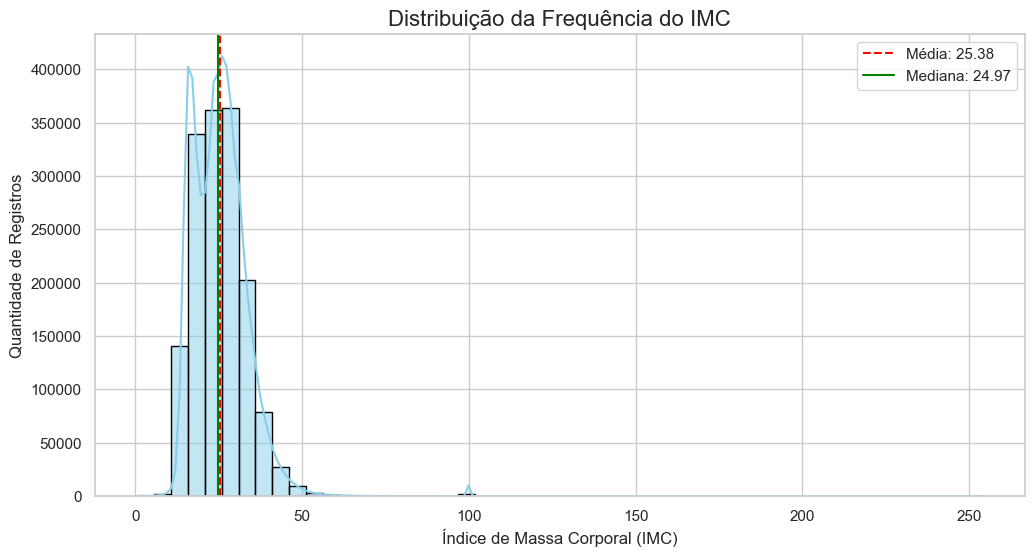

In [76]:
plt.figure(figsize=(12, 6))

sns.set_theme(style="whitegrid")
sns.histplot(data=clean_target_dataset,
             x='DS_IMC',
             kde=True,        
             bins=50,         
             color='skyblue',
             edgecolor='black')

plt.axvline(clean_target_dataset['DS_IMC'].mean(), color='red', linestyle='--', label=f'Média: {clean_target_dataset["DS_IMC"].mean():.2f}')
plt.axvline(clean_target_dataset['DS_IMC'].median(), color='green', linestyle='-', label=f'Mediana: {clean_target_dataset["DS_IMC"].median():.2f}')

plt.title('Distribuição da Frequência do IMC', fontsize=16)
plt.xlabel('Índice de Massa Corporal (IMC)', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)
plt.legend()

plt.show()

Os gráficos a seguir mostram a relação entre o IMC e a Idade. No primeiro, é possível identificar outliers, como IMCs próximos a 200, o que é 'impossível' e talvez um erro de digital. Acho q é melhor  manter apenas os registros onde o IMC está entre 10 e 100.

Também exibimos as 'Fases da Vida'. Decidimos manter essa coluna para o modelo não precisar 'adivinhar' as mudanças biológicas sozinho; com ela, garantimos que a divisão dos grupos (criança, adulto, idoso) funcione perfeitamente.

A Fase da Vida ajuda o modelo a entender o desbalanceamento: crianças e idosos têm pouquíssimos casos de IMC muito baixo ou muito alto.

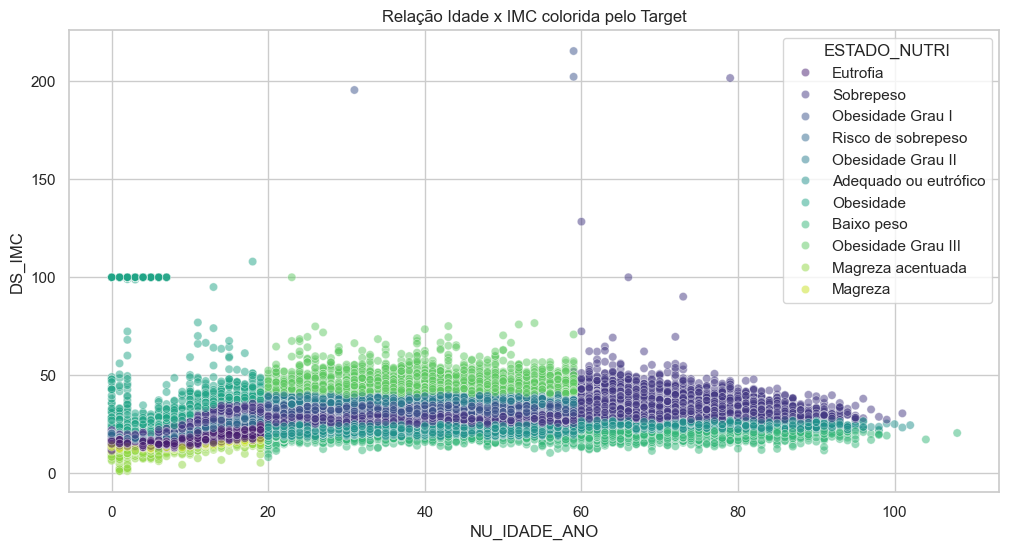

In [77]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=clean_target_dataset.sample(100000), x='NU_IDADE_ANO', y='DS_IMC', hue='ESTADO_NUTRI', palette='viridis', alpha=0.5)
plt.title('Relação Idade x IMC colorida pelo Target')
plt.show()

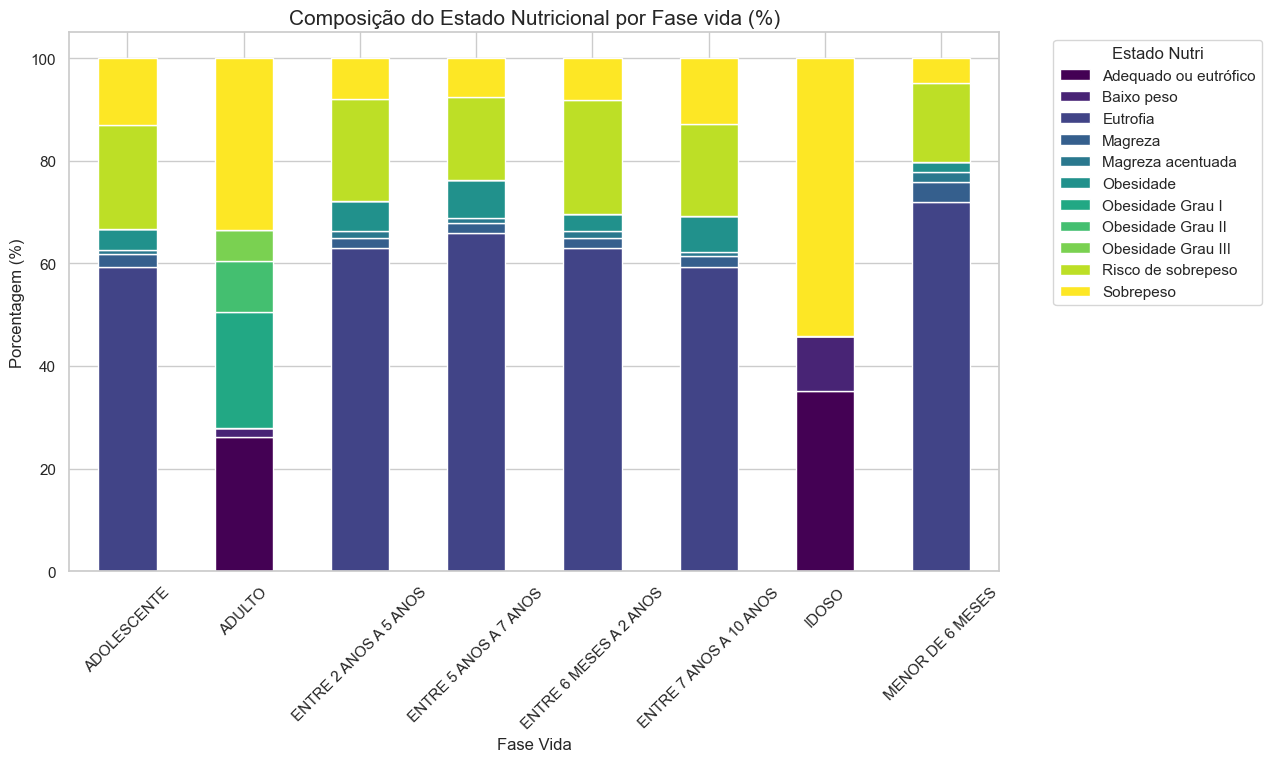

In [78]:
prop_fase_vida = pd.crosstab(clean_target_dataset["DS_FASE_VIDA"], clean_target_dataset["ESTADO_NUTRI"], normalize='index') * 100
prop_fase_vida.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Composição do Estado Nutricional por Fase vida (%)', fontsize=15)
plt.legend(title='Estado Nutri', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Fase Vida')
plt.xticks(rotation=45)
plt.show()

O gráfico acima mostra que a maior concentração de obesidade e sobrepeso estão nas fases adultos e idosos, sendo que idosos tem muito mais sobrepeso, mais da metade deste grupo está com sobrepeso.  
Isso ocorre porque a maioria das pessoas não se cuida ao envelhecer, geralmente continuam comendo mal e sem fazer exercícios enquanto o metabolismo e outras partes do corpo vao se degradando, ficando piores com o passar do tempo.  
Isso é um alerta para os orgãos de saúde focarem na disciplinação de idosos e adultos.

Abaixo vamos adcionar o sexo em um gráfico Sankey Diagram para vermos se algum sexo em determinada faixa etária tem mais propenção a obesidade do que outro.

In [79]:
import plotly.graph_objects as go

# 2. Criar a lista de labels únicos para todos os nós
# A ordem aqui define os índices (0, 1, 2...)
label_list = list(clean_target_dataset['DS_FASE_VIDA'].unique()) + \
             list(clean_target_dataset['SG_SEXO'].unique()) + \
             list(clean_target_dataset['ESTADO_NUTRI'].unique())

# 3. Mapear os nomes para seus respectivos índices
nodes_map = {name: i for i, name in enumerate(label_list)}

# 4. Construir as conexões (Source -> Target)
# Fluxo 1: Fase da Vida -> Sexo
flow1 = clean_target_dataset.groupby(['DS_FASE_VIDA', 'SG_SEXO']).size().reset_index(name='count')
# Fluxo 2: Sexo -> Estado Nutri
flow2 = clean_target_dataset.groupby(['SG_SEXO', 'ESTADO_NUTRI']).size().reset_index(name='count')

sources = [nodes_map[x] for x in flow1['DS_FASE_VIDA']] + [nodes_map[x] for x in flow2['SG_SEXO']]
targets = [nodes_map[x] for x in flow1['SG_SEXO']] + [nodes_map[x] for x in flow2['ESTADO_NUTRI']]
values = list(flow1['count']) + list(flow2['count'])

# 5. Gerar o gráfico
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = label_list,
      color = "royalblue"
    ),
    link = dict(
      source = sources,
      target = targets,
      value = values,
      color = 'rgba(173, 216, 230, 0.4)' # Cor suave para os fluxos
  ))])

fig.update_layout(title_text="Fluxo: Fase da Vida > Sexo > Estado Nutricional", font_size=12)
fig.show()


Observando o gráfico acima, podemos ver que adultos do sexo feminino tem uma concentração mnuito maior de obesidade e sobrepeso do que o sexo masculino.  
Logo a atenção deve ser voltada ainda mais para as mulheres nesta faixa etária.

### Adicionando o cálculo do % Gordura a partir da fórmula de Deuremberg, que leva em conta idade e sexo.

- **Para Adultos:** $1.51 \times \text{IMC} - 0.70 \times \text{Idade} - 3.6 \times \text{sexo} + 1.4$ ($R^2$ 0.38 e SEE 4%, segundo o documento original)
- **Para crianças até 15 anos:** $1.20 \times \text{IMC} + 0.23 \times \text{Idade} - 10.8 \times \text{sexo} - 5.4$ ($R^2$ 0.79 e SEE 4.1%, segundo o documento original)

**Onde:** Masculino = 1 e Feminino = 0

#### Classificação do Percentual de Gordura Corporal

**Homens**


| Classificação | 20–29 anos | 30–39 anos | 40–49 anos | 50–59 anos | 60+ anos |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Excelente | < 11% | < 12% | < 14% | < 15% | < 16% |
| Bom | 11–13% | 12–15% | 14–17% | 15–18% | 16–19% |
| Acima da média | 14–20% | 16–21% | 18–23% | 19–24% | 20–25% |
| Abaixo da média | 21–23% | 22–24% | 24–26% | 25–27% | 26–28% |
| Ruim | > 23% | > 24% | > 26% | > 27% | > 28% |

**Mulheres**


| Classificação | 20–29 anos | 30–39 anos | 40–49 anos | 50–59 anos | 60+ anos |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Excelente | < 16% | < 17% | < 18% | < 19% | < 20% |
| Bom | 16–19% | 17–20% | 18–21% | 19–22% | 20–23% |
| Acima da média | 20–28% | 21–29% | 22–30% | 23–31% | 24–32% |
| Abaixo da média | 29–31% | 30–32% | 31–33% | 32–34% | 33–35% |
| Ruim | > 31% | > 32% | > 33% | > 34% | > 35% |

---

**Fontes:**

**DEURENBERG, P.; WESTSTRATE, J. A.; SEIDELL, J. C.** Body mass index as a measure of body fatness: age- and sex-specific prediction formulas. *British Journal of Nutrition*, Cambridge, v. 65, n. 2, p. 105–114, mar. 1991.  
DOI: [10.1079/BJN19910073](https://doi.org).  
Disponível em: [https://nih.gov](https://nih.gov).  
Acesso em: 01 abr. 2026.

American College of Sports Medicine. ACSM's Health-Related Physical Fitness Assessment Manual. 2nd ed. Philadelphia: Lippincott Williams & Wilkins, 2008. p. 59.

> **OBS:** a fórmula de Deuremberg foi desenvolvida principalmente em populações caucasianas europeias, então deve-se considerar alguma margem de erro em populações como a do Brasil, que tem maior diversidade étnica.

In [80]:
clean_target_dataset.head()

,NU_IDADE_ANO,DS_FASE_VIDA,SG_SEXO,NU_PESO,NU_ALTURA,DS_IMC,ESTADO_NUTRI
0,47,ADULTO,M,114.5,178.0,36.14,Obesidade Grau II
1,62,IDOSO,F,65.0,148.0,29.67,Sobrepeso
2,29,ADULTO,F,132.0,168.0,46.77,Obesidade Grau III
3,1,ENTRE 6 MESES A 2 ANOS,F,13.3,90.0,16.42,Eutrofia
4,43,ADULTO,F,54.0,152.0,23.37,Adequado ou eutrófico


In [81]:
clean_target_dataset['PERC_GORDURA'] = np.where(
    clean_target_encoded_dataset['NU_IDADE_ANO'] <=15,
    1.51 * clean_target_encoded_dataset['DS_IMC'] - 0.70 * clean_target_encoded_dataset['NU_IDADE_ANO'] - 3.6 * (1 - clean_target_encoded_dataset['SG_SEXO'] + 1.4),
    1.20 * clean_target_encoded_dataset['DS_IMC'] - 0.23 * clean_target_encoded_dataset['NU_IDADE_ANO'] - 10.8 * (1 - clean_target_encoded_dataset['SG_SEXO'] - 5.4))

clean_target_dataset['PERC_GORDURA'] = clean_target_dataset['PERC_GORDURA'].round(2)
clean_target_encoded_dataset['PERC_GORDURA'] = clean_target_dataset['PERC_GORDURA'].copy() # Replica para a base encoded

clean_target_dataset.head()

,NU_IDADE_ANO,DS_FASE_VIDA,SG_SEXO,NU_PESO,NU_ALTURA,DS_IMC,ESTADO_NUTRI,PERC_GORDURA
0,47,ADULTO,M,114.5,178.0,36.14,Obesidade Grau II,90.88
1,62,IDOSO,F,65.0,148.0,29.67,Sobrepeso,68.86
2,29,ADULTO,F,132.0,168.0,46.77,Obesidade Grau III,96.97
3,1,ENTRE 6 MESES A 2 ANOS,F,13.3,90.0,16.42,Eutrofia,15.45
4,43,ADULTO,F,54.0,152.0,23.37,Adequado ou eutrófico,65.67


Agora vamos analisar a relação entre peso X imc e peso X percentual de gordura.

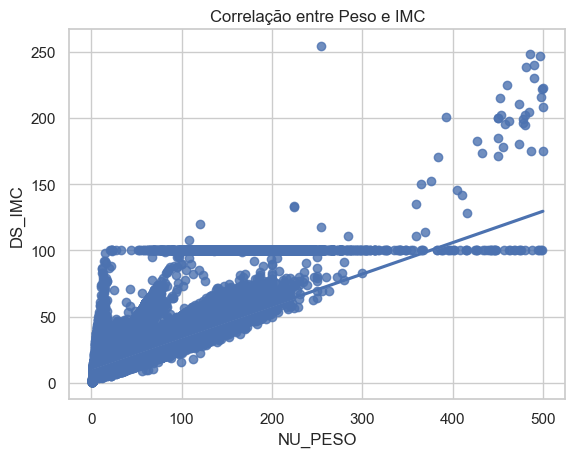

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criando o gráfico de dispersão com uma linha de tendência
sns.regplot(x='NU_PESO', y='DS_IMC', data=clean_target_dataset)

plt.title('Correlação entre Peso e IMC')
plt.show()


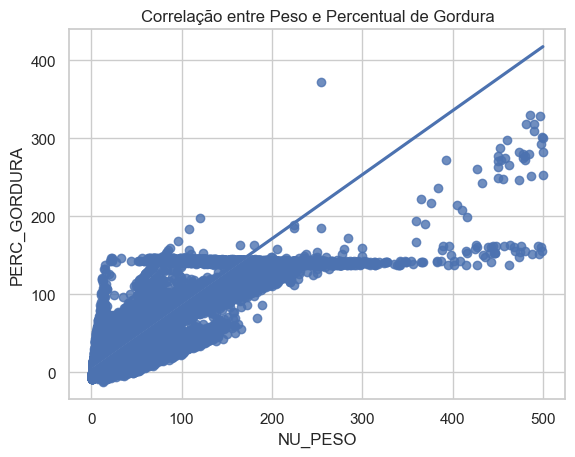

In [83]:
# Criando o gráfico de dispersão com uma linha de tendência
sns.regplot(x='NU_PESO', y='PERC_GORDURA', data=clean_target_dataset)

plt.title('Correlação entre Peso e Percentual de Gordura')
plt.show()


Observando os gráficos, vemos uma relação entre o peso e as outras medidas.  
Em sua maioria, enquanto o peso sobe, o IMC e percentual de gordura também sobem.  
Também fica evidente em ambos gráficos uma linha em IMC 100 e percentual de gordura em 150 mais ou menos.  
Esses são os casos mais gráves em pessoas com menos peso e menos grave conforme o peso vai aumentando.  
Além disso podemos observar algums pontos esporádicos a direita superior, que são uma pequena concentrações de pessoas naquele estado, os outliers.

Abaixo, vamos analisar qual é a correlação entre todos as variáveis da nossa base. Para isso vamos utilizar um mapa de calor.

<Axes: >

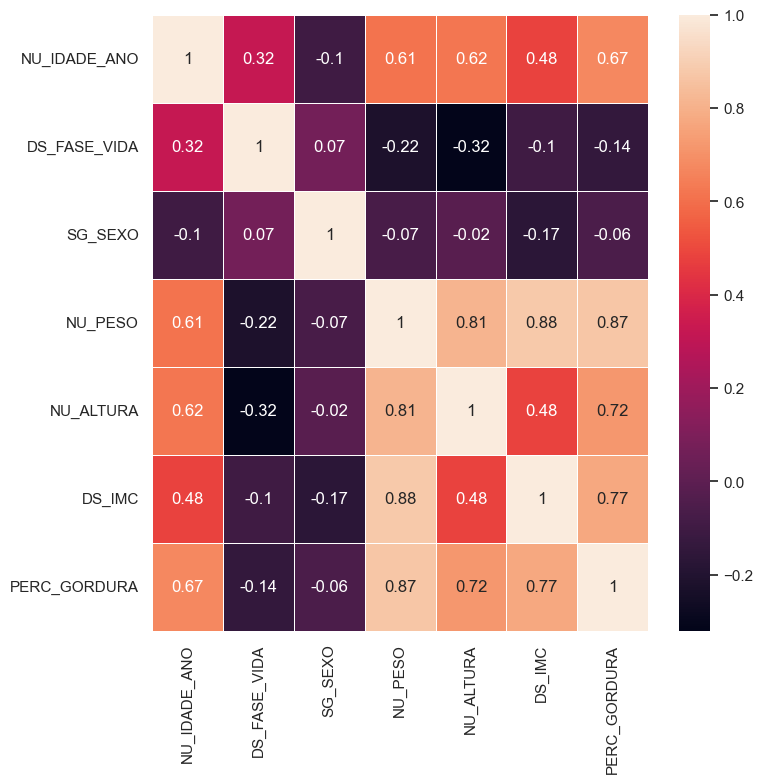

In [84]:
only_vars = clean_target_encoded_dataset.drop("ESTADO_NUTRI", axis=1)
correlation_matrix = only_vars.corr().round(2)

_, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

Analisando este gráfico, podemos notar algumas correlações fortes, como por exemplo IMC X Peso, que tem 0.88 de correlação entre eles.  
Percentual de Gordura tem uma relação forte com a Idade, então quanto mais velha é uma pessoa, mais peso ela tem.  
O Peso também tem um relação forte com a Idade, logo quanto mais velha é a pessoa, mais peso ela possui.  
Outra relação bem forte é do Peso X Altura, logo quanto mais alta a pessoa é, mais peso ela possui.  
Além desses, os outros dados que possuem correlação >= 0.48 também possuem uma forte correlação.

Feita as análises e ajustes sobre a nossa base de dados, vamos separá-la em base de treino e teste.  
Para isso, vamos separar as variáveis do target e usar a função **train_test_split** do pacote **scikit-learn**.    

Como temos 2 medidas de pesos diferentes (IMC e Percentual de Gordura), vamos ver como o modelo se comporta com cada uma individual e com ambas juntas.    

Vamos começar usando o IMC.

In [85]:
from sklearn.model_selection import train_test_split

x_vars = clean_target_encoded_dataset[["NU_IDADE_ANO", "DS_FASE_VIDA", "SG_SEXO", "NU_PESO", "NU_ALTURA", "DS_IMC"]].copy()
y_target = clean_target_encoded_dataset["ESTADO_NUTRI"].copy()

x_train_vars, x_test_vars, y_train_targ, y_test_targ = train_test_split(x_vars, y_target, test_size=0.3, stratify=y_target, random_state=28)


Explicando os paramâtros passados no **train_test_split**. Isso é muito importante para ter qualidade no treinamento e nos resultados finais.

* **test_size=0.3**: Define que **30%** dos dados totais serão reservados para o conjunto de teste, enquanto os **70%** restantes serão usados para o treinamento do modelo.

* **stratify=y_target**: Garante que a divisão mantenha a mesma **proporção** das classes da variável alvo (`y`) tanto no treino quanto no teste. Isso evita que o modelo seja treinado ou testado com uma distribuição de categorias diferente da realidade do dataset original.

* **random_state=7**: Define uma "semente" para o gerador de números aleatórios. Usar um valor fixo (como o 7) garante que a separação dos dados seja **reproduzível**, ou seja, o código sempre entregará os mesmos conjuntos de treino e teste ao ser executado novamente.


Abaixo podemos ver que ambas as bases ficaram com quase com a mesma proporção de registros.

In [86]:
y_train_targ.value_counts(normalize=True) * 100

ESTADO_NUTRI
Sobrepeso                29.496798
Eutrofia                 21.615191
Adequado ou eutrófico    18.888673
Obesidade Grau I         10.160833
Risco de sobrepeso        6.800131
Obesidade Grau II         4.534042
Baixo peso                2.938192
Obesidade Grau III        2.720742
Obesidade                 1.652029
Magreza                   0.803561
Magreza acentuada         0.389809
Name: proportion, dtype: float64

In [87]:
y_test_targ.value_counts(normalize=True) * 100

ESTADO_NUTRI
Sobrepeso                29.496789
Eutrofia                 21.615370
Adequado ou eutrófico    18.888667
Obesidade Grau I         10.160954
Risco de sobrepeso        6.800129
Obesidade Grau II         4.534071
Baixo peso                2.938223
Obesidade Grau III        2.720617
Obesidade                 1.651935
Magreza                   0.803468
Magreza acentuada         0.389778
Name: proportion, dtype: float64

Existem algums modelos que vão atender muito bem no nosso cenário. Vamos testar alguns deles, começando pelo mais simples, o **K-Nearst Neighbors**.  

Basicamente ele recebe um dado novo e procura quais N dados conhecidos mais se tem caracteristicas semelhantes ao novo dado e o classifica de acordo com estes "vizinhos" (dai vem o nome do classificador). Aonde N é a quantidade de vizinhos informados ao inicializar o modelo.

Acredito que ele vai funcionar bem aqui porque indivíduos com peso, altura e idade semelhantes tendem a ter o mesmo estado nutricional. É simples e intuitivo para este cenário.

In [88]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_imc = KNeighborsClassifier(n_neighbors=10)
knn_imc.fit(x_train_vars, y_train_targ)

knn_prediction = knn_imc.predict(x_test_vars)

print(classification_report(y_test_targ, knn_prediction))


                       precision    recall  f1-score   support

Adequado ou eutrófico       0.99      1.00      1.00     86889
           Baixo peso       0.99      0.97      0.98     13516
             Eutrofia       0.97      0.99      0.98     99432
              Magreza       0.83      0.75      0.79      3696
    Magreza acentuada       0.95      0.79      0.86      1793
            Obesidade       0.94      0.93      0.93      7599
     Obesidade Grau I       0.99      1.00      0.99     46741
    Obesidade Grau II       0.98      0.98      0.98     20857
   Obesidade Grau III       0.99      0.98      0.99     12515
   Risco de sobrepeso       0.92      0.91      0.92     31281
            Sobrepeso       0.99      0.98      0.99    135687

             accuracy                           0.98    460006
            macro avg       0.96      0.93      0.95    460006
         weighted avg       0.98      0.98      0.98    460006



In [89]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_targ, knn_prediction)
print(f"Acurácia Global: {accuracy:.2%}")


Acurácia Global: 97.91%


Acima podemos ver o relatório de precisão do modelo e a taxa de acurácia global. Foram bons números, o modelo consegue acertar mais de 90% dos casos.  

Agora vamos ver os resultados em uma matriz de confusão para vermos com mais clareza aonde nosso modelo errou e acertou.  

Quanto maior a concentração de numeros na diagonal da esquerda para a direita, maior é a taxa de acerto do modelo.

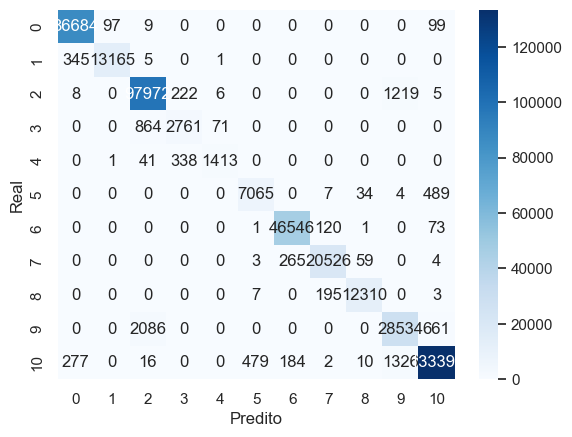

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_targ, knn_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()


Agora vamos usar o mesmo modelo porém com a variável percentual de gordura ao invés do IMC.

In [91]:
x_vars = clean_target_encoded_dataset[["NU_IDADE_ANO", "DS_FASE_VIDA", "SG_SEXO", "NU_PESO", "NU_ALTURA", "PERC_GORDURA"]].copy()
y_target = clean_target_encoded_dataset["ESTADO_NUTRI"].copy()

x_train_vars, x_test_vars, y_train_targ, y_test_targ = train_test_split(x_vars, y_target, test_size=0.3, stratify=y_target, random_state=28)

knn_prec_g = KNeighborsClassifier(n_neighbors=10)
knn_prec_g.fit(x_train_vars, y_train_targ)

knn_prediction = knn_prec_g.predict(x_test_vars)

print(classification_report(y_test_targ, knn_prediction))


                       precision    recall  f1-score   support

Adequado ou eutrófico       0.99      1.00      0.99     86889
           Baixo peso       0.99      0.96      0.98     13516
             Eutrofia       0.97      0.99      0.98     99432
              Magreza       0.83      0.76      0.80      3696
    Magreza acentuada       0.94      0.77      0.85      1793
            Obesidade       0.94      0.94      0.94      7599
     Obesidade Grau I       0.99      1.00      0.99     46741
    Obesidade Grau II       0.98      0.98      0.98     20857
   Obesidade Grau III       0.99      0.98      0.99     12515
   Risco de sobrepeso       0.92      0.91      0.92     31281
            Sobrepeso       0.99      0.98      0.99    135687

             accuracy                           0.98    460006
            macro avg       0.96      0.93      0.95    460006
         weighted avg       0.98      0.98      0.98    460006



In [92]:
accuracy = accuracy_score(y_test_targ, knn_prediction)
print(f"Acurácia Global: {accuracy:.2%}")

Acurácia Global: 97.87%


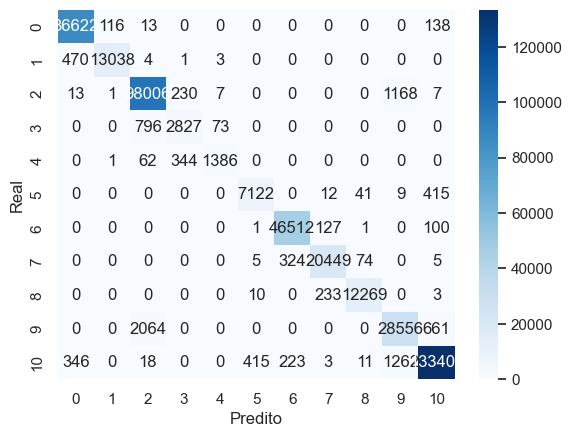

In [93]:
cm = confusion_matrix(y_test_targ, knn_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()


Analisando ambos resultados, podemos ver que são extremamente semelhantes, então é indiferente qual dos valores vamos usar para o treinamento.  

Agora vamos ver como o modelo se comporta com os 2 dados.

In [94]:
x_vars = clean_target_encoded_dataset[["NU_IDADE_ANO", "DS_FASE_VIDA", "SG_SEXO", "NU_PESO", "NU_ALTURA", "PERC_GORDURA", "DS_IMC"]].copy()
y_target = clean_target_encoded_dataset["ESTADO_NUTRI"].copy()

x_train_vars, x_test_vars, y_train_targ, y_test_targ = train_test_split(x_vars, y_target, test_size=0.3, stratify=y_target, random_state=28)

knn_prec_g = KNeighborsClassifier(n_neighbors=10)
knn_prec_g.fit(x_train_vars, y_train_targ)

knn_prediction = knn_prec_g.predict(x_test_vars)

print(classification_report(y_test_targ, knn_prediction))

                       precision    recall  f1-score   support

Adequado ou eutrófico       0.99      1.00      0.99     86889
           Baixo peso       0.99      0.97      0.98     13516
             Eutrofia       0.97      0.99      0.98     99432
              Magreza       0.84      0.77      0.80      3696
    Magreza acentuada       0.95      0.80      0.87      1793
            Obesidade       0.94      0.94      0.94      7599
     Obesidade Grau I       0.99      1.00      0.99     46741
    Obesidade Grau II       0.98      0.98      0.98     20857
   Obesidade Grau III       0.99      0.98      0.99     12515
   Risco de sobrepeso       0.92      0.91      0.92     31281
            Sobrepeso       0.99      0.98      0.99    135687

             accuracy                           0.98    460006
            macro avg       0.96      0.94      0.95    460006
         weighted avg       0.98      0.98      0.98    460006



In [95]:
accuracy = accuracy_score(y_test_targ, knn_prediction)
print(f"Acurácia Global: {accuracy:.2%}")

Acurácia Global: 97.94%


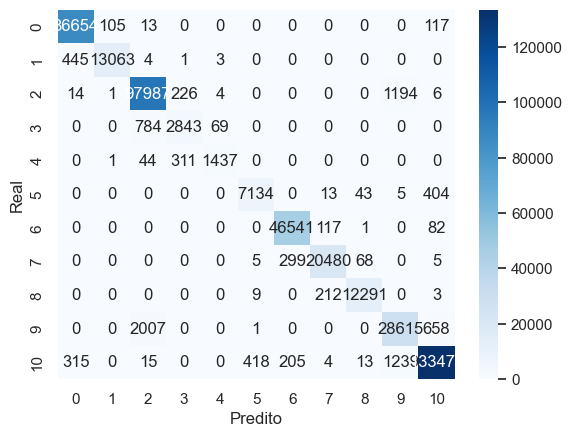

In [96]:
cm = confusion_matrix(y_test_targ, knn_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Com ambas variáveis, podemos notar que o modelo teve uma leve melhora na taxa de acurácia. Cerca de 0,04 %.

Agora vamos testar um modelo mais robusto, o **RandomForestClassifier**.   

Ele é um modelo de aprendizado de máquina que combina várias árvores de decisão para criar um "comitê" mais robusto e preciso. Ele funciona sob o princípio de que um conjunto de modelos fracos (árvores individuais) pode formar um modelo forte.

O funcionamento baseia-se em quatro etapas principais: 
1) **Bootstrap (Amostragem Aleatória)**: O modelo cria diferentes subconjuntos dos dados de treino selecionando linhas aleatoriamente com reposição.
2) **Criação das Árvores**: Uma árvore de decisão é construída para cada subconjunto. Em cada divisão (split) de um nó, o algoritmo escolhe apenas um subconjunto aleatório de colunas (features), o que garante que as árvores sejam diferentes entre si e não fiquem excessivamente correlacionadas.
3) **Predição Individual**: Cada árvore na "floresta" gera sua própria previsão para um novo dado.
4) **Votação Majoritária (Aggregation)**: O resultado final do classificador é a classe que recebeu mais "votos" entre todas as árvores.


É importante entender e configurar corretamente alguns parâmetros deste modelo, são eles:

- **n_estimators**: Define o número de ávores na floresta. Default = 100.
- **n_jobs**: É número de nucleos do processador que vão rodar em paralelo. -1 = Utiliza todos os núcleos em paralelo.
- **max_depth**: Controla a profundidade de cada árvore (ramificações), evitando overfiting.
- **verbose**: Exibe ou omite o progresso do treinamento, útil para esperas longas. 1 = Exibe o progresso.
- **random_state**: É a mesma coisa da função **train_test_split**, gera um seed para reproduzir a mesma aleatoriedade sempre que executado.


In [97]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20, 
    n_jobs=-1, 
    verbose=1,
    random_state=28
)

rf_model.fit(x_train_vars, y_train_targ)

rf_prediction = rf_model.predict(x_test_vars)

print(classification_report(y_test_targ, rf_prediction))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    9.5s finished
[Parallel(n_jobs=28)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=28)]: Done 100 out of 100 | elapsed:    0.6s finished


                       precision    recall  f1-score   support

Adequado ou eutrófico       1.00      1.00      1.00     86889
           Baixo peso       1.00      1.00      1.00     13516
             Eutrofia       0.98      0.98      0.98     99432
              Magreza       0.89      0.86      0.88      3696
    Magreza acentuada       0.95      0.92      0.94      1793
            Obesidade       0.96      0.95      0.96      7599
     Obesidade Grau I       1.00      1.00      1.00     46741
    Obesidade Grau II       1.00      1.00      1.00     20857
   Obesidade Grau III       1.00      1.00      1.00     12515
   Risco de sobrepeso       0.92      0.93      0.93     31281
            Sobrepeso       0.99      0.99      0.99    135687

             accuracy                           0.99    460006
            macro avg       0.97      0.97      0.97    460006
         weighted avg       0.99      0.99      0.99    460006



In [98]:
print(f"\nAcurácia Geral: {accuracy_score(y_test_targ, rf_prediction):.2%}")


Acurácia Geral: 98.62%


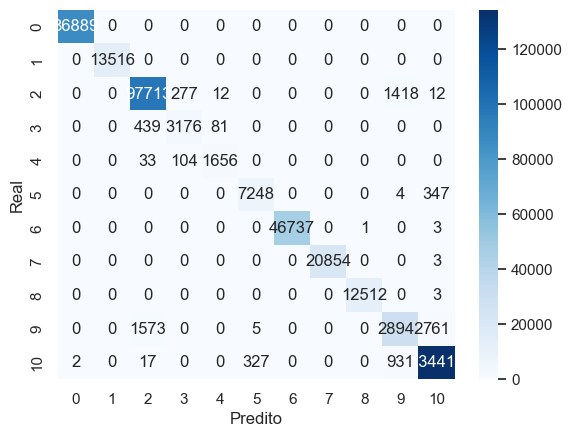

In [99]:
cm = confusion_matrix(y_test_targ, rf_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Avaliando os resultados da RandomForestClassifier podemos notar um aumento de 0.68% de acurácia, totalizando 98.62%, um excelente resultado.  

Com esse modelo também conseguimos identificar quais variáveis tiveram mais relevancia na hora da classificação. Abaixo geramos esse gráfico.

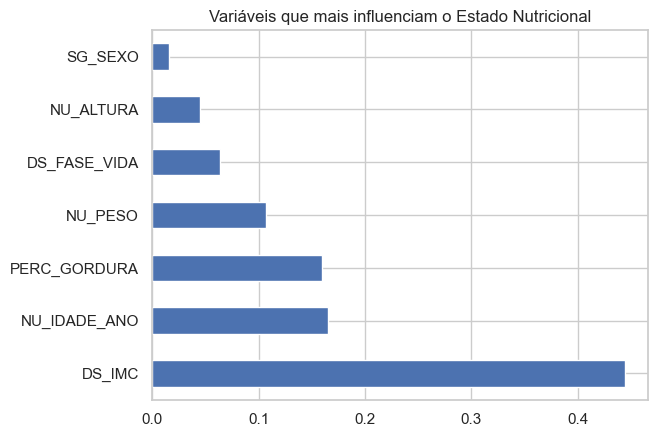

In [100]:
# Criando um ranking das variáveis mais importantes
importancias = pd.Series(rf_model.feature_importances_, index=x_train_vars.columns)
importancias.nlargest(10).plot(kind='barh')
plt.title('Variáveis que mais influenciam o Estado Nutricional')
plt.show()


Podemos ver claramente que o IMC foi a variável mais relevante para a classificação.

Vamos remover a variável IMC e ver como o modelo se comporta.

In [101]:
x_vars = clean_target_encoded_dataset[["NU_IDADE_ANO", "DS_FASE_VIDA", "SG_SEXO", "NU_PESO", "NU_ALTURA", "PERC_GORDURA"]].copy()
y_target = clean_target_encoded_dataset["ESTADO_NUTRI"].copy()

x_train_vars, x_test_vars, y_train_targ, y_test_targ = train_test_split(x_vars, y_target, test_size=0.3, stratify=y_target, random_state=28)

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20, 
    n_jobs=-1, 
    verbose=1,
    random_state=28
)

rf_model.fit(x_train_vars, y_train_targ)

rf_prediction = rf_model.predict(x_test_vars)

print(classification_report(y_test_targ, rf_prediction))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    9.6s finished
[Parallel(n_jobs=28)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=28)]: Done 100 out of 100 | elapsed:    0.6s finished


                       precision    recall  f1-score   support

Adequado ou eutrófico       1.00      1.00      1.00     86889
           Baixo peso       1.00      1.00      1.00     13516
             Eutrofia       0.98      0.98      0.98     99432
              Magreza       0.89      0.86      0.87      3696
    Magreza acentuada       0.95      0.92      0.93      1793
            Obesidade       0.96      0.95      0.95      7599
     Obesidade Grau I       1.00      1.00      1.00     46741
    Obesidade Grau II       1.00      1.00      1.00     20857
   Obesidade Grau III       1.00      1.00      1.00     12515
   Risco de sobrepeso       0.93      0.92      0.93     31281
            Sobrepeso       0.99      0.99      0.99    135687

             accuracy                           0.99    460006
            macro avg       0.97      0.96      0.97    460006
         weighted avg       0.99      0.99      0.99    460006



In [102]:
print(f"\nAcurácia Geral: {accuracy_score(y_test_targ, rf_prediction):.2%}")


Acurácia Geral: 98.56%


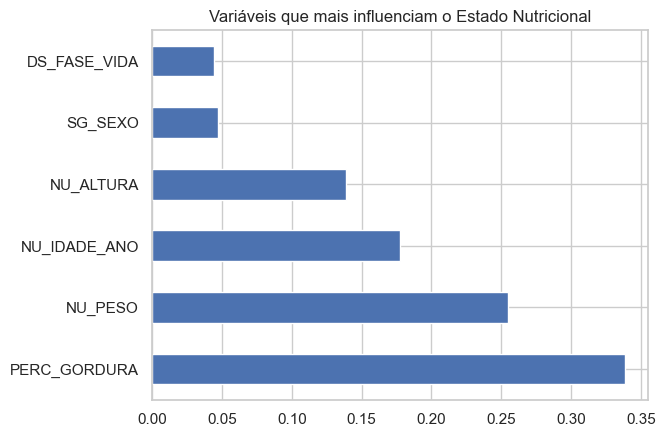

In [103]:
# Criando um ranking das variáveis mais importantes
importancias = pd.Series(rf_model.feature_importances_, index=x_train_vars.columns)
importancias.nlargest(10).plot(kind='barh')
plt.title('Variáveis que mais influenciam o Estado Nutricional')
plt.show()

Removendo o IMC, podemos ver que ele deu mais importância para as outras variáveis, ficou menos concentrada a importância em uma só variável.  
Os resultados foram bem semelhantes, sem o IMC foi de 98.62% para 98.56%, pouquissima diferença.